   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-

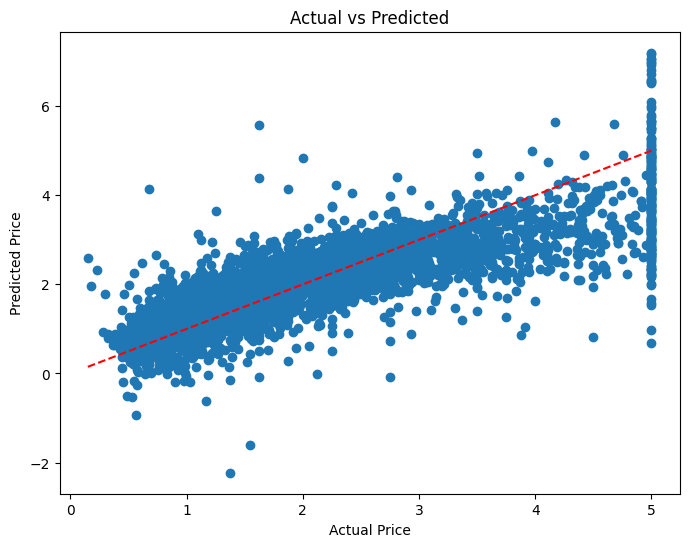

In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score



housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print(df.head())
print(df.info())
print(df.describe())




df["Rooms_per_Household"] = df["AveRooms"] / df["HouseAge"]
df["Bedrooms_per_Room"] = df["AveBedrms"] / df["AveRooms"]
df["Population_per_Household"] = df["Population"] / df["AveOccup"]

# Features and Target

X = df.drop("Price", axis=1)
y = df["Price"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

results = []

for name, model in models.items():

    if name == "Decision Tree":
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, rmse, r2])

    print("=" * 50)
    print(name)
    print("RMSE :", rmse)
    print("R2 Score :", r2)


results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R2 Score"]
)

print("\nPerformance Comparison")
print(results_df)



best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nBest Model")
print(best_model)



linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

pred = linear.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()